# Solphin Full Workflow

At current this is only tested in inorganic semiconductor (non-perovskite) photovoltaic materials.

Calculating the Photovoltaic figure of merit requires various data characterising a material's optoelectronic properties. Solphin provides methods to automate/assist calculating these properties using VASP (the Vienna Ab-initio Simulation Package).

In [1]:
#import the required modules

import logging
import os

import numpy as np
from matplotlib import pyplot as plt

import solphin.band_structure as band_structure
import solphin.db_fom as db_fom
import solphin.db_plots as db_plotting
import solphin.dos as dos
import solphin.final_results as final_results
import solphin.optics as optics
import solphin.spectral as spectral
import solphin.vasp_inputs as vasp_inputs

# solphin does not configure logging - that is the application's job, and here
# the notebook is the application. sumo reports the k-path and structure
# symmetry through the root logger at INFO, so opt in to see it; matplotlib's
# font_manager is turned down because sumo's style sheet asks for fonts
# (cursive, sans:semibold) that no machine has, and the fallback is fine.
logging.basicConfig(level=logging.INFO)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

%load_ext autoreload
%autoreload 2
%matplotlib inline

## Using Solphin to generate VASP input files

### Where files are read from and written to

This notebook has two halves: the first generates VASP *input* files, the second analyses VASP *output* files. It never runs VASP itself, so the outputs analysed below cannot have come from the inputs generated above — they ship with the repository.

* `../tests/data/Cu2GeS3/` is **reference data, tracked in git** — the same calculation set the test suite runs against. Every `vasprun.xml`, `CONTCAR`, `IBZKPT` and `.dat` file read below comes from there. Nothing in this notebook writes into it, so re-running the whole notebook leaves it byte-identical.
* `workdir/` is **generated and disposable**. Every input set written below lands there under the same subdirectory names, so you can compare what you just generated against the reference calculation that produced the shipped results:

  ```bash
  diff workdir/Relax/INCAR ../tests/data/Cu2GeS3/Relax/INCAR
  ```

  It is gitignored and re-created on the next run. Delete it whenever you like — and do delete it before re-running with a different `splits`, or the previous run's `split-NN` folders are left behind beside the new ones.

The generation cells need VASP pseudopotentials (`PMG_VASP_PSP_DIR`), which are licensed and cannot be redistributed. Without them, skip ahead to *Analysing the Results of VASP Calculations*; that half runs on the shipped data alone.

To run this workflow on your own material, point `data_directory` at your own calculation and leave `workdir` where it is.


### Global Settings

These settings should apply to all calculations in the workflow, and are the essential first choice of a DFT study. You must choose:

- Appropiate values for the `ENCUT` and `KSPACING` for your system. Convergence testing is the commonly used method of determining the appropiate values, see [here](https://github.com/kavanase/vaspup2.0).

- A functional. It is recommended to use hybrid DFT (HSE06 or PBE0) when investigating PV materials to achieve high-quality publishable results.

In [2]:
functional = 'HSE06'  # The DFT functional
encut = 450  # Plane-wave energy cutoff
kspacing = 0.2  # k-point sampling density

# Read root: the Cu2GeS3 reference calculation set shipped with the test
# suite. Nothing below writes here.
data_directory = '../tests/data/Cu2GeS3'

# Write root: everything this notebook generates. Disposable and gitignored.
workdir = 'workdir'
os.makedirs(workdir, exist_ok=True)

### Geometry Optimisation / Relaxation

The initial step of any DFT structural property study is a geometry optimisation to find the lowest energy arrangement of the atoms in your system. For this you need:

- A starting structure, this can be obtained from the ICSD, the Materials Project, or experimental studies. Placeholder currently accepts  the VASP POSCAR/CONTCAR, .cif, .xyz, or .json formats.



In [3]:
# Set the structure filename and calculation settings

# Reference calculation (read-only): the starting structure, and the relaxed
# CONTCAR that the rest of the notebook is built on.
relax_directory = f'{data_directory}/Relax'
initial_structure = f'{relax_directory}/POSCAR'

# The folder you want to run the calculation in.
relax_out = f'{workdir}/Relax'

In [4]:
# Load the structure
structure = vasp_inputs.read_structure_pmg(initial_structure)

# Generate the calculations
vasp_inputs.write_vasp_calculation(
    structure=structure,
    recipe=functional,
    out_dir=relax_out,
    patches=['relax_cell', 'tight_relax'],
    user_incar_settings={"KSPACING": kspacing, "ENCUT": encut})

Once the relaxation calculation is complete, we load the relaxed structure to use as the basis for the rest of our calculations:

This notebook does not run VASP, so the `CONTCAR` below is read from the shipped `../tests/data/Cu2GeS3/Relax` reference calculation rather than from the `workdir/Relax` input set just written. On your own material, run the calculation you generated and read *its* `CONTCAR` here.

In [5]:
# Load the structure
contcar = f'{relax_directory}/CONTCAR'
structure = vasp_inputs.read_structure_pmg(contcar)

### Electronic Density of States and Optical Absorption

* This calculation produces the optoelectronic data we need.

* This time the structure we feed in is the `CONTCAR` generated in the previous step, which contains our "relaxed" or "optimised" structure.

* To get the most accurate results, the shape of the Density of States and optical absorption spectrum should be sufficiently converged with respect to `KSPACING` and `NBANDS`.

In [6]:
#Set the output directory for the optics calculation
optics_directory = f'{data_directory}/OPT_hybrid'  # shipped results, read below
optics_out = f'{workdir}/OPT_hybrid'  # generated inputs

In [7]:
# Generate the calculation
vasp_inputs.write_vasp_calculation(
    structure=structure,
    recipe=functional,
    out_dir=optics_out,
    patches=["optics"],
    user_incar_settings={"KSPACING": kspacing, "ENCUT": encut, "ISPIN": 1, "ISMEAR": -5, "SIGMA": 0.02, "LORBIT": 14})

### Band Structure

The electronic band structure of a material shows the relationship between the different possible electronic states and their distribution in momentum space. This is important for determining the band gap of the system.

- To reduce the three-dimensional momentum space into a single axis, we sample points along a specific high-symmetry path. 
- There are different choices of definition for this path, but all require a "canonical" orientation of the structure with respect to the axes.

In [8]:
#Calcualate the high symmetry path for our structure, and ensure we work with the canonical orientation
canonical_structure, band_path = band_structure.generate_band_structure_path(structure=structure,
                                                                             definition="bradcrack")

INFO:root:Structure information:


INFO:root:	Space group number: 9


INFO:root:	International symbol: Cc


INFO:root:	Lattice type: monoclinic


INFO:root:
k-point path:
	\Gamma -> Y -> V -> \Gamma -> A -> M -> L -> V


...

INFO:root:	M: 0.5 0.5 0.5


INFO:root:	L: 0.5 0.0 0.5


INFO:root:	V: 0.5 0.0 0.0


INFO:root:	Y: 0.5 0.5 0.0


Generated high-symmetry path of 239 k-points


- Since all k-points are independent problems, we can split this task into multiple parallel calculations to improve efficiency. This is usually only necessary if using a hybrid functional.

- If using a hybrid functional, we also need to include some additional k-points in each calculation - the same ones we used in our DOS/Optics.

In [9]:
functional = "HSE06"

# Shipped band-structure results, read in the analysis section below.
band_directory = f"{data_directory}/BAND_SP_HDFT"

# Where this notebook writes the band-structure input sets.
band_out = f"{workdir}/BAND_SP_HDFT"

# How many parallel calculations to split the k-point path across.
splits = 5

# The shipped calculation in band_directory was run as 7 splits by an earlier
# version of this workflow, so it is a different number from `splits` above and
# no value of `splits` reproduces it. Only the analysis cell below uses this.
band_splits = 7

# A hybrid band structure needs the SCF irreducible k-points, which come from
# the shipped optics calculation.
scf_kpoints = f"{optics_directory}/IBZKPT"
scf_charge = None

In [10]:
band_structure.write_band_structure_calculation(
    structure=canonical_structure,
    kpath=band_path,
    band_directory=band_out,
    functional=functional,
    splits=splits,
    scf_charge=scf_charge,
    scf_kpoints=scf_kpoints,
    user_incar_settings={"ENCUT": encut})

## Analysing the Results of VASP Calculations

### Electronic Density of States/Optics

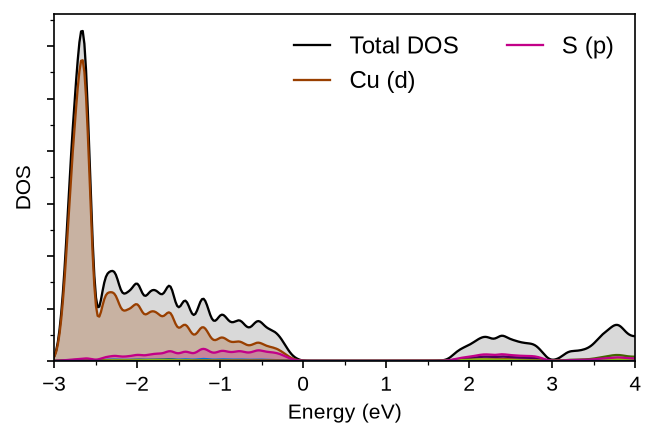

In [11]:
dos.plot_dos(filename=f'{optics_directory}/vasprun.xml', xmin=-3, xmax=4, gaussian=0.05, save=False)

In [12]:
dos.write_eff_mass(
    k0_frac=np.array([0.0, 0.0, 0.0]),
    structure=structure,
    functional="HSE06",
    encut=450,
    folder=f'{workdir}/eff_mass',
)

In [13]:
result = dos.compute_dos(
    dos_vasprun=f"{data_directory}/DOS_HDFT/vasprun.xml",
    carrier="electrons",
    energy_window=0.1,
)

print(result)

print(
    "Mass passed to FOM:",
    result.final_result,
    "m_e",
)

dos_mass = result.final_result

/home/louie/miniconda3/envs/solphin/lib/python3.11/site-packages/pymatgen/io/vasp/outputs.py:1369: UserWarning: No POTCAR file with matching TITEL fields was found in

  if potcar := self.get_potcars(path):
/home/louie/miniconda3/envs/solphin/lib/python3.11/site-packages/pymatgen/io/vasp/outputs.py:1380: UserWarning: No POTCAR file with matching TITEL fields was found in

  potcar = self.get_potcars(path)


  Computing electron FOM DOS effective mass...
  Computing hole FOM DOS effective mass...

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  Carrier            : electrons
  Fitted mass        : 0.072754 m_e
  Fit quality        : R² = 0.671063
  DOS points fitted  : 7

  This DOS calculation does not contain enough well-resolved
  near-edge DOS data to determine the Crovetto DOS effective
  mass reliably.

  Consider either:
    1. Re-running the DOS calculation with a denser regular k-point grid.
    2. Supplying an alternative effective-mass estimate if a denser
       hybrid-functional calculation is prohibitively expensive.

  The current fitted mass should therefore be treated as provisional.

  Fitting-window behaviour:

  FOM DOS effective-mass convergence (electrons)
 Window / eV     m_DOS / m_e           R²        N
--------------------------------------------------------------------

      0.1000        0.072754     0.671063        7
      0.1500        0.103528     0.640706       11
      0.2000        0.134423     0.626624       15
      0.2500        0.165404     0.618299       19


      0.3000        0.196409     0.612909       23
      0.4000        0.389845     0.233687       30


  DOS Result Summary
  Primary carrier     : Electrons
  Band edge (CBM)     : 1.402 eV
  Cell volume         : 2.234e-28 m³

  ── FOM DOS Effective Masses ───────────────────────
  Electrons (fitted at CBM: 1.402 eV)
  DOS effective mass    : 0.072754 mₑ  (6.627e-32 kg)  ← FOM DOS mass
  Fit quality           : 0.671063 R²
  Points fitted         : 7
  Energy window         : 0.1000 eV


  Holes (fitted at VBM: 0.000 eV)
  DOS effective mass    : 0.775865 mₕ  (7.068e-31 kg)
  Fit quality           : 0.596060 R²
  Points fitted         : 7
  Energy window         : 0.1000 eV


Mass passed to FOM: 0.07275405447841903 m_e


### Optical Absorption Spectrum

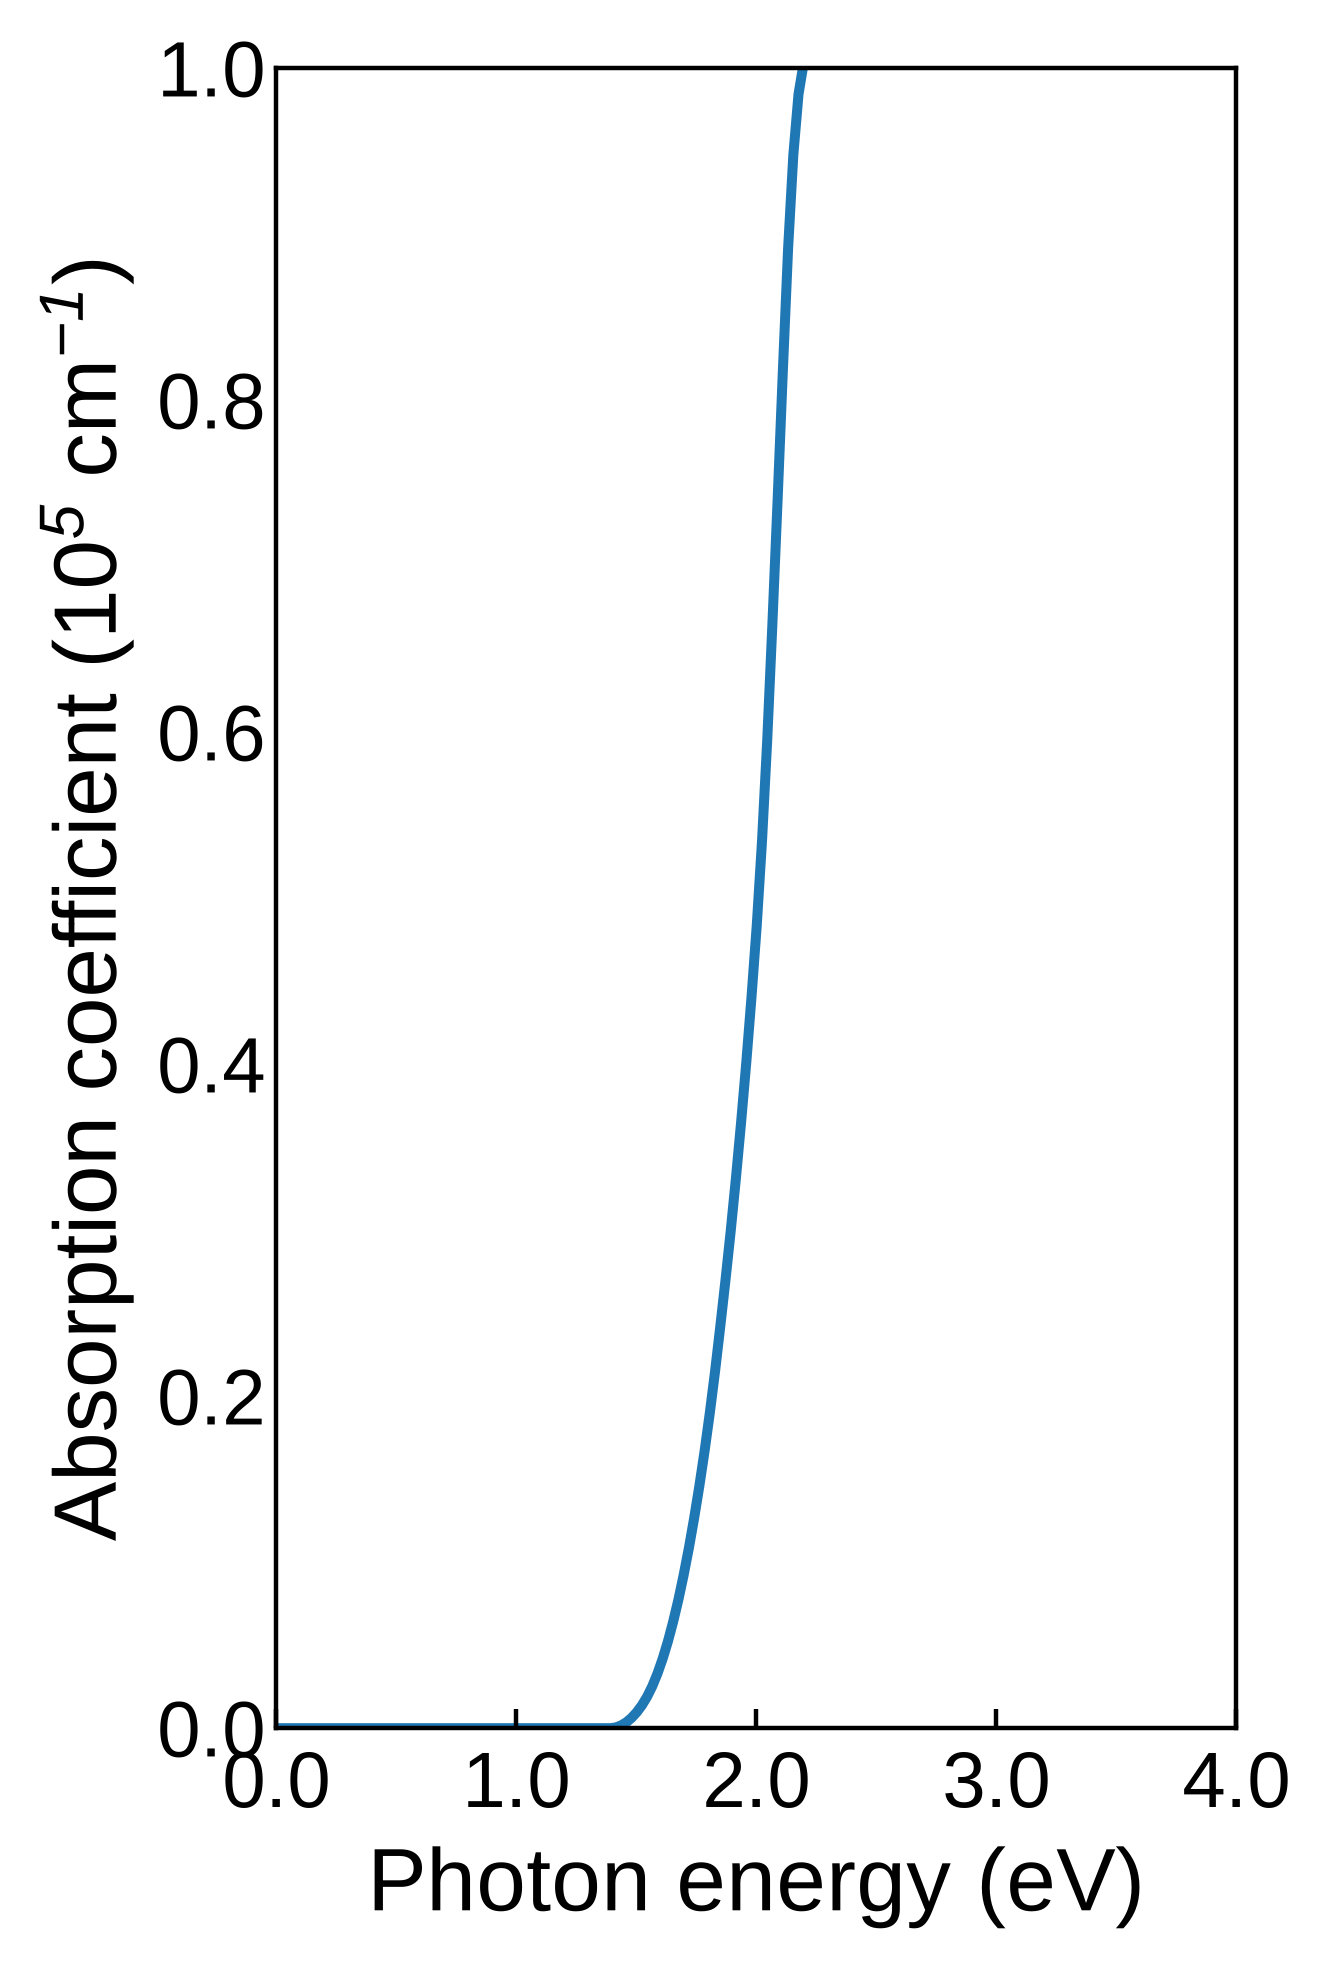

In [14]:
optics.plot_absorption(optics_directory=optics_directory)

##### Optical/High-Frequency/Static Dielectric Constant

In [15]:
eps_inf, eps_inf_tensor, _, _, _ = optics.calc_dielectric(filename=f'{optics_directory}/vasprun.xml')

print("E_∞:", eps_inf)

print("")
print("E_∞ tensor:")
print(eps_inf_tensor)

E_∞: 6.109433333333333

E_∞ tensor:
[[ 6.0546  0.     -0.0644]
 [ 0.      6.1405 -0.    ]
 [-0.0644 -0.      6.1332]]


### Band Structure

INFO:root:Label positions:


INFO:root:	0.0000: $\Gamma$


INFO:root:	0.5549: Y


INFO:root:	1.1383: V


INFO:root:	1.7216: $\Gamma$


INFO:root:	3.3740: L


INFO:root:	3.8880: V


Band Gap = 1.3900999999999994 eV, \Gamma-\Gamma


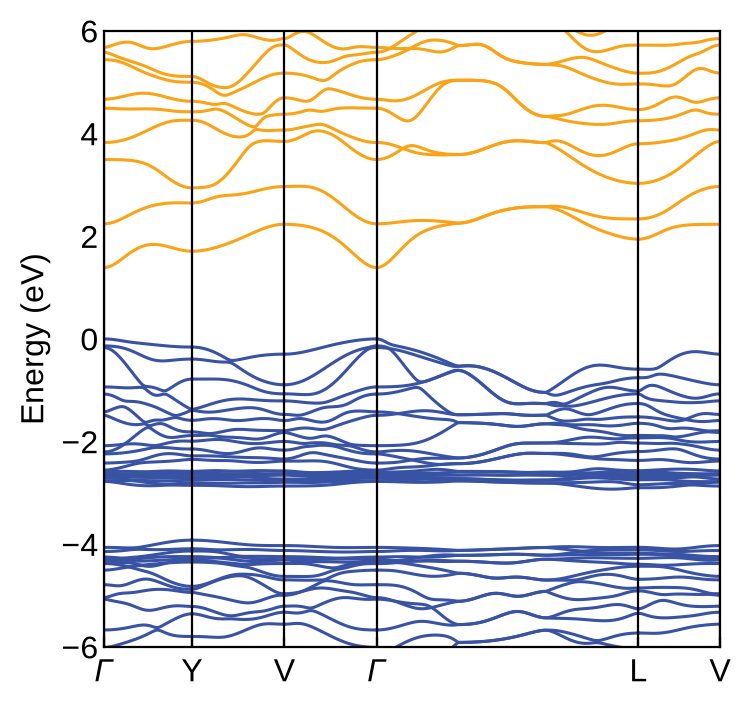

In [16]:
#Extract (and recombine) vaspruns to create a single band structure object.
#This reads the shipped results rather than the inputs generated above, so it
#uses band_splits (7 shipped folders), not the generation-side `splits`.
bs = band_structure.get_band_structure(band_directory, band_splits)

#Plot the band structure, with the DOS alongside if desired
fig, ax = plt.subplots(figsize=(4, 4), dpi=200)
band_structure.plot_band_structure(bs, plt, ymin=-6, ymax=6)

#Extract the band gap for use in the FOM and report it
fundamental_gap = bs.get_band_gap()
E_gap_fundamental = fundamental_gap["energy"]
E_gap_direct = bs.get_direct_band_gap()
print(f"Band Gap = {E_gap_fundamental} eV, {fundamental_gap['transition']}")

## Calculating the SLME and Blank et al. metrics

In [17]:
spectrum_type = "AM1.5"  # One of "AM1.5", "Fluorescent", "Blue LED", "Green LED", "Red LED", "White LED", "IR LED", "Photopic"
spectrum = db_fom.load_spectrum(spectrum_type=spectrum_type)

In [18]:
# Generates n_real.dat and absorption.dat for use in SLME and Blank et al.
# They go into workdir/: regenerating them is not bit-identical (they differ from
# the shipped copies at ~1e-14), so writing them back over the reference data
# would show up as a git diff. The cells below deliberately keep reading the
# shipped originals, which the test suite certifies.
os.makedirs(optics_out, exist_ok=True)

optics.generate_n_real(optics_directory, out_directory=optics_out)
optics.generate_absorption(optics_directory, out_directory=optics_out)

### SLME

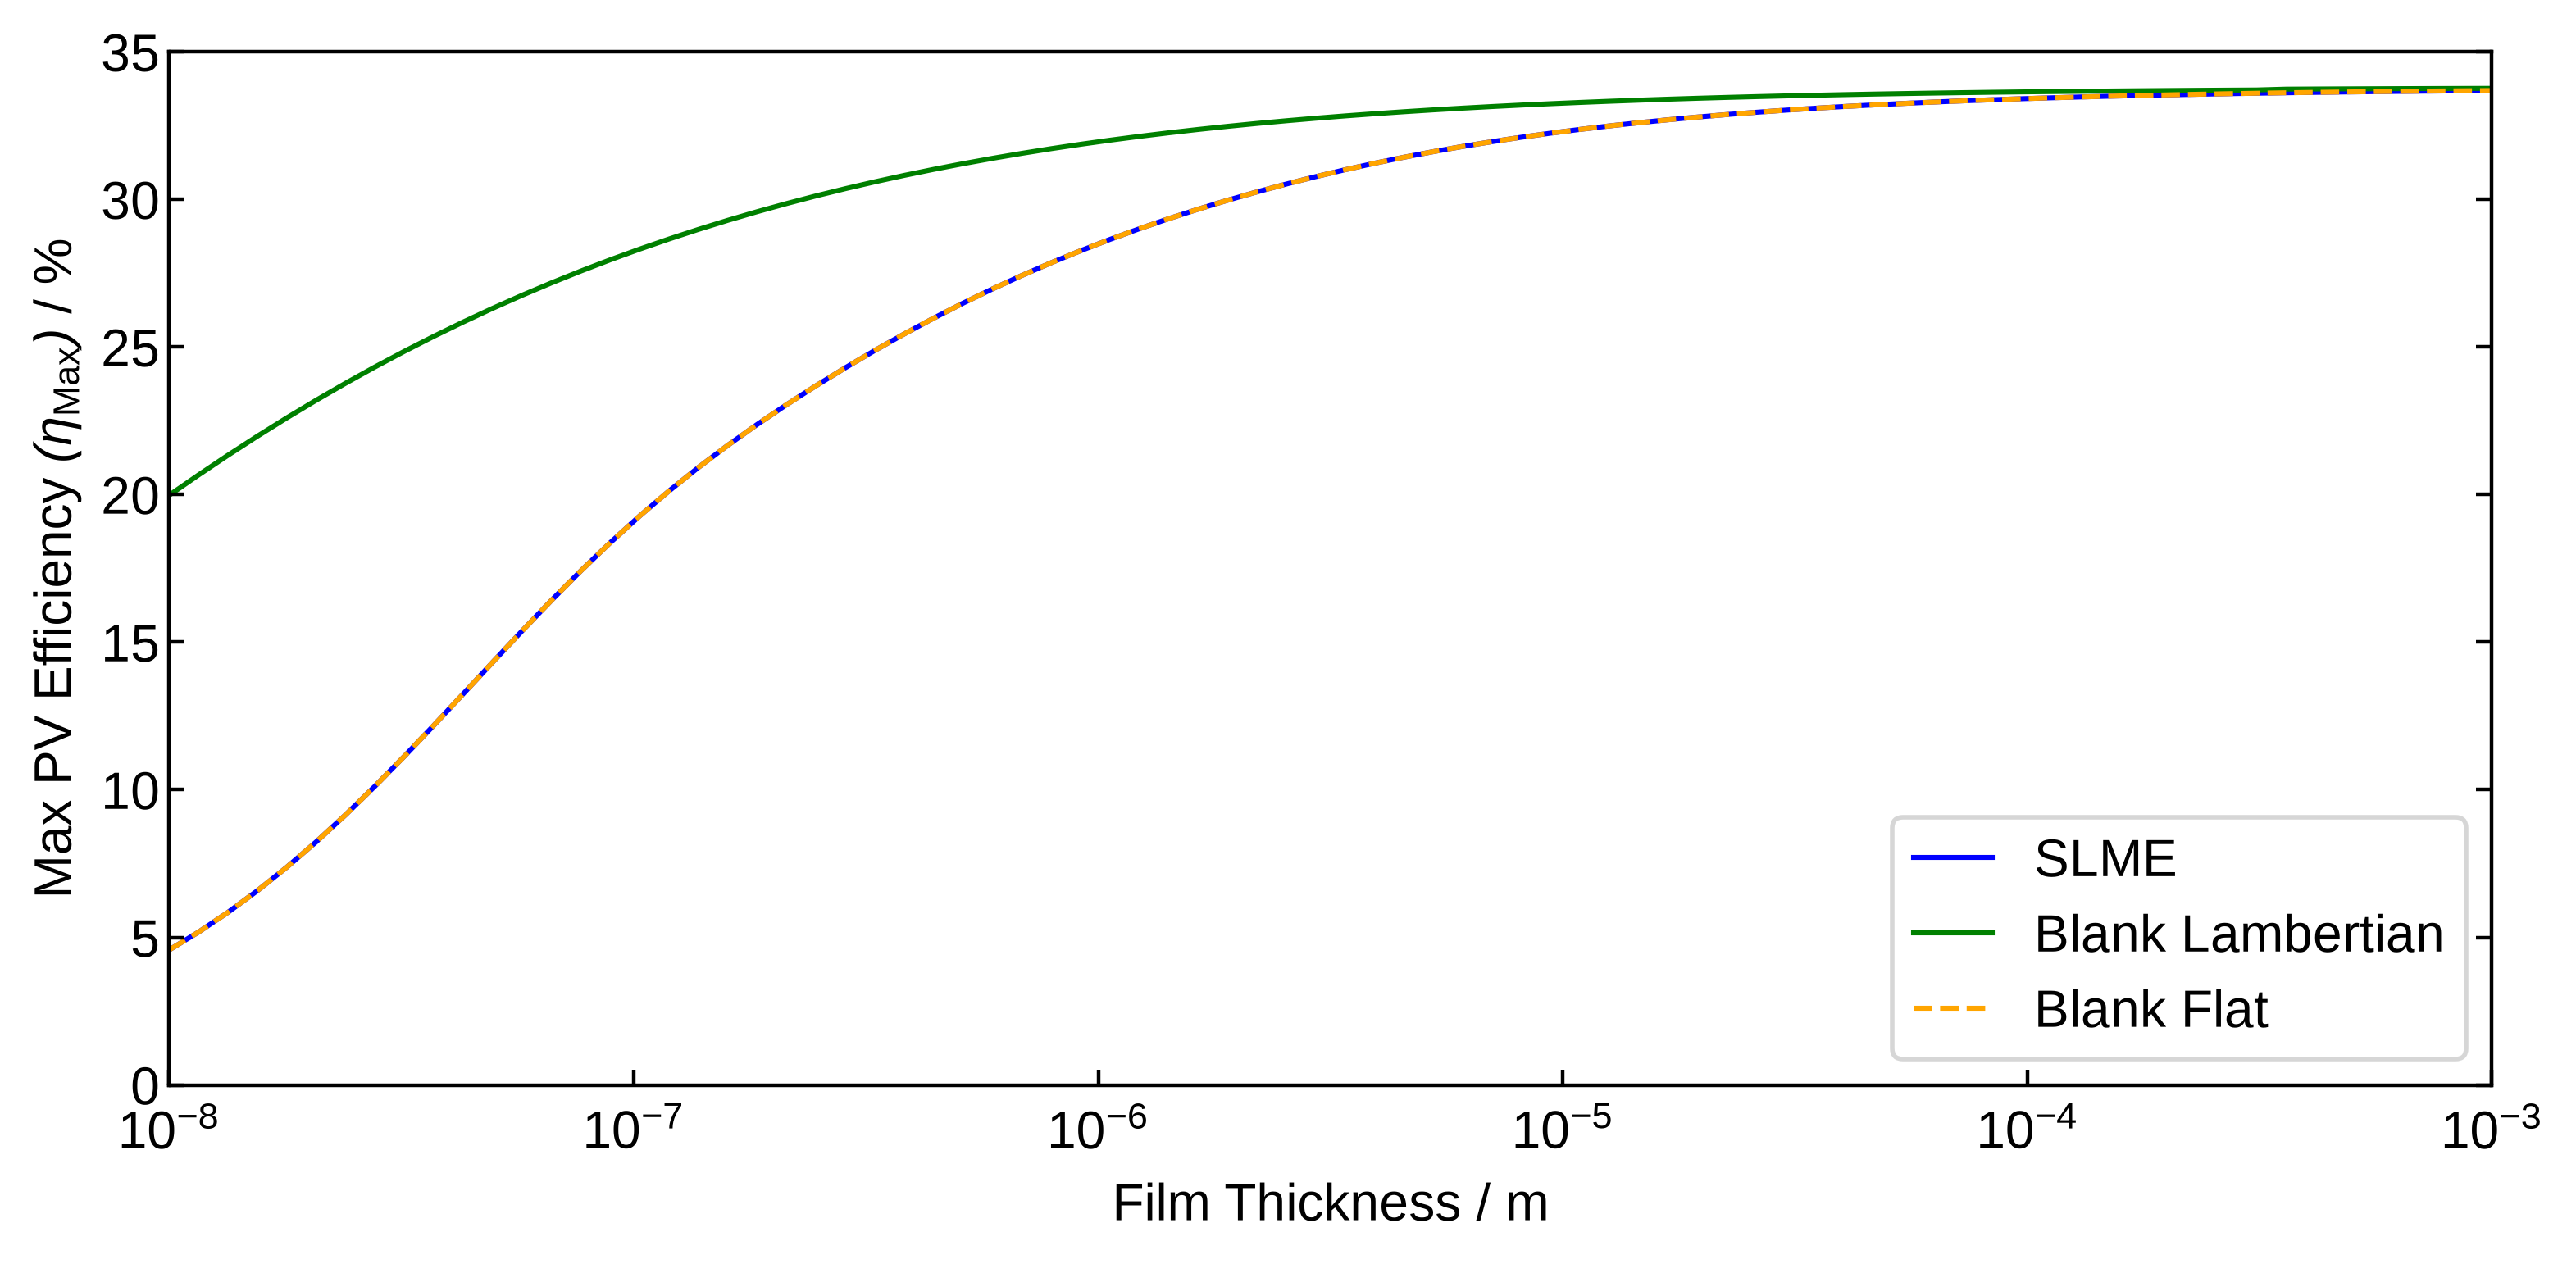

In [19]:
optics.make_blank_plot(optics_directory, direct_gap=E_gap_direct, indirect_gap=E_gap_direct, spectrum_type="AM1.5",
                       Qi=1.0, n=3.5, thickness_range=None, save=False)

## Obtaining the Detailed Balance and Shockley-Queisser Limit

By supplying a band gap (eV) and operating temperature (K), the Detailed Balance results can be obtained and plotted.

In [20]:
# Define the operating temperature of the cell and Fundamental band gap (?)

Tcell = 300  # Operating Temperature
spectrum_type = "AM1.5"  # One of "AM1.5", "Fluorescent", "Blue LED", "Green LED", "Red LED", "White LED", "IR LED", "Photopic"

# Convert the spectrum
spectrum = db_fom.load_spectrum(spectrum_type=spectrum_type)
photon_spectrum = db_fom.convert_spectrum(spectrum)

This can also be done interactively:

interactive(children=(FloatSlider(value=1.6, description='Band Gap (eV)', layout=Layout(width='800px'), max=3.…

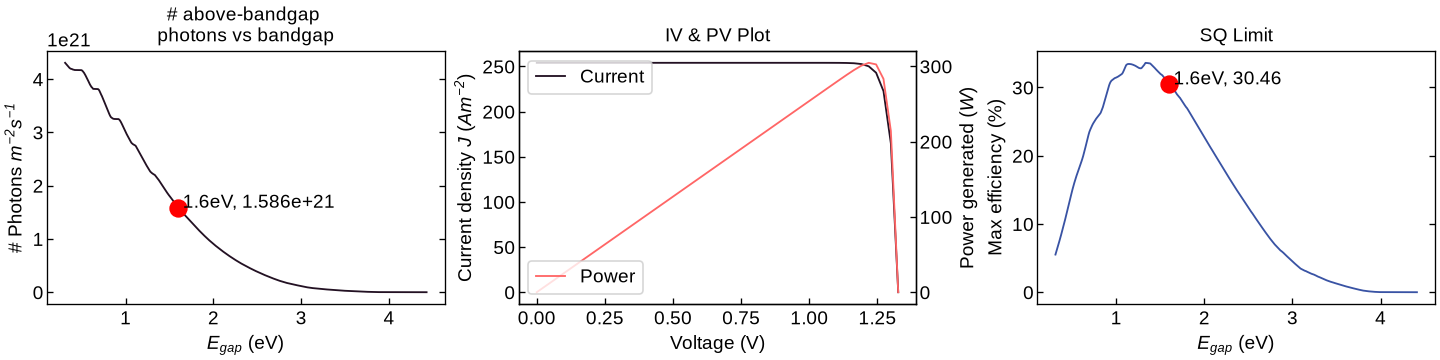

In [21]:
%matplotlib widget
db_plotting.plot_db_combined_interactive()

## Calculating The Photovoltaic Figure of Merit

This section brings together various properties to calculate the Photovoltaic Figure of Merit. Some of these must be manually specified - taken from other sources or representative values. Any of the calculated values from previous sections can be manually overwritten.

In [22]:
spectral_average, spectral_dispersion = spectral.generate_spectral_parameters(optics_directory, spectrum,
                                                                              E_gap=E_gap_direct)

In [23]:
# MAPI values

# E_gap = 1.55               # E₉ Electronic Band gap (eV)
# spectral_average = 9.9e4   # Spectral average (alpha), (cm⁻¹)
# spectral_dispersion = 0.63 # Spectral dispersion (sigma), (unitless)
# dos_mass = 0.15            # m density of states effective mass (m₀)
# eps_inf = 33.5             # E_∞ Electronic/Optical/Static dielectric constant (unitless)
# tau = 6.9e-7               # Carrier lifetime (s)
# mu = 10                    # Carrier mobility (cm²V⁻¹s⁻¹)
# dopant_density = 1e12      # Doping density (cm⁻³)

In [24]:
# Set default values from Crovetto et al.

tau = 1e-6
doping_density = 1e10
mu = 1e6

In [25]:
#Calculate the FoM using the efficiency metric
sq, fom_sq, eff = final_results.SQ_relative_FOM_PV_efficiency(E_gap_direct, photon_spectrum, spectral_average, tau,
                                                              spectral_dispersion, dos_mass, doping_density, eps_inf,
                                                              mu, Tcell)
print(f"Photovoltaic Figure of Merit relative to the SQ limit: {fom_sq:.2f} %")
print(f"Photovoltaic Figure of Merit total efficiency: {eff:.2f} %")
print(f"SQ limit: {sq:.2f} %")

Photovoltaic Figure of Merit relative to the SQ limit: 80.61 %
Photovoltaic Figure of Merit total efficiency: 27.01 %
SQ limit: 33.51 %


In [26]:
final_results.print_final_result_interactive(E_gap_direct, photon_spectrum, spectral_average, tau, spectral_dispersion,
                                             dos_mass, doping_density, eps_inf, mu, Tcell)

interactive(children=(FloatLogSlider(value=10000000000.0, description='Doping Density (cm⁻³)', layout=Layout(w…

interactive(children=(FloatLogSlider(value=10000000000.0, description='Doping Density (cm⁻³)', layout=Layout(w…

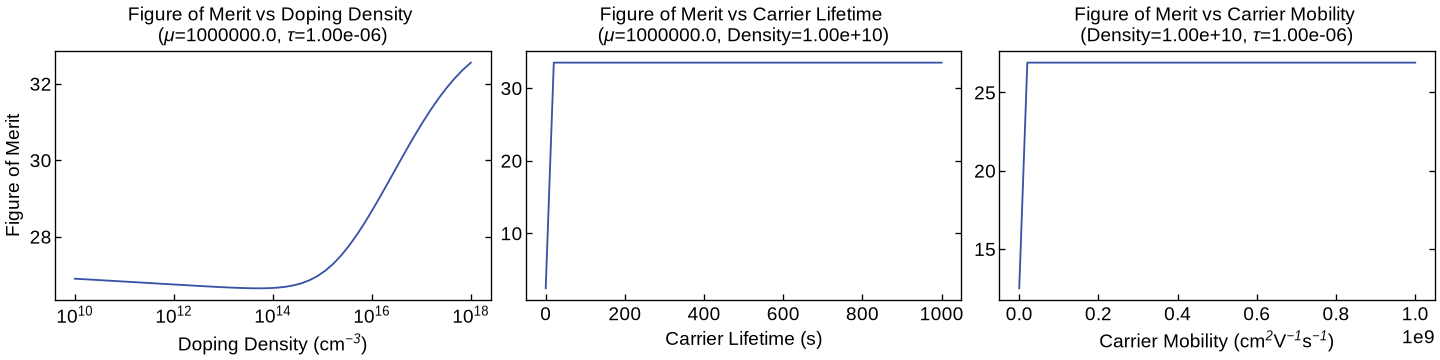

In [27]:
%matplotlib widget
final_results.plot_final_result_interactive(E_gap_direct, photon_spectrum, spectral_average, tau, spectral_dispersion,
                                            dos_mass, doping_density, eps_inf, mu, Tcell)